## Exercise 4.09 - Intro to Data Visualization with Python

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [5]:
# create path
path='/home/haus/Exercise_4_Instacart_Basket_Analysis'

In [7]:
# Importing ords_prods_merge
df_exe409=pd.read_pickle(r'/home/haus/Exercise_4_Instacart_Basket_Analysis/02_Data/Prepared_Data/aggregated_ords_prods_merge.pkl')

### Bar Charts

<Axes: xlabel='order_dow'>

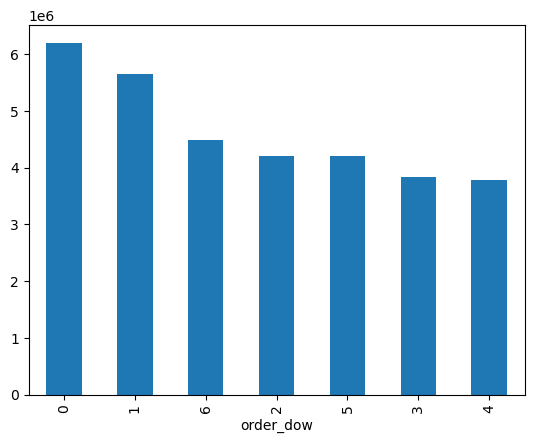

In [10]:
# Create a bar chart (order from largest to smallest)
df_exe409['order_dow'].value_counts().plot.bar()

<Axes: xlabel='order_dow'>

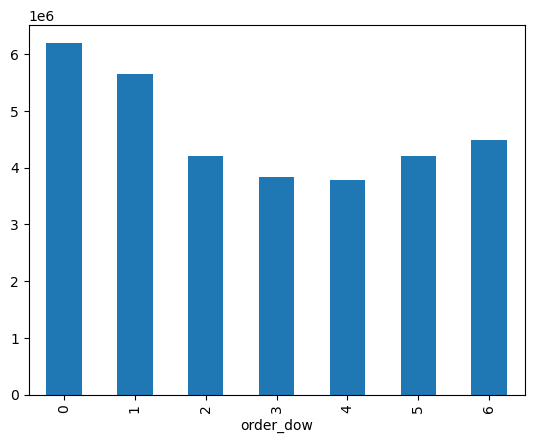

In [12]:
# Chage the order in a bar chart (change from largest to smallest order to an index order)
df_exe409['order_dow'].value_counts().sort_index().plot.bar()

<Axes: xlabel='order_dow'>

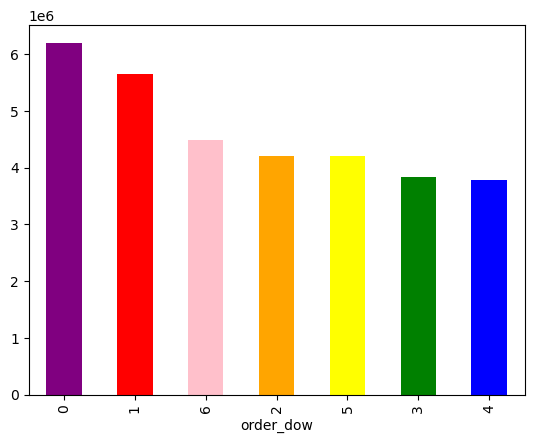

In [14]:
# Create a bar chart (change bar chart colour)
df_exe409['order_dow'].value_counts().plot.bar(color=['purple', 'red', 'pink', 'orange', 'yellow', 'green', 'blue'])

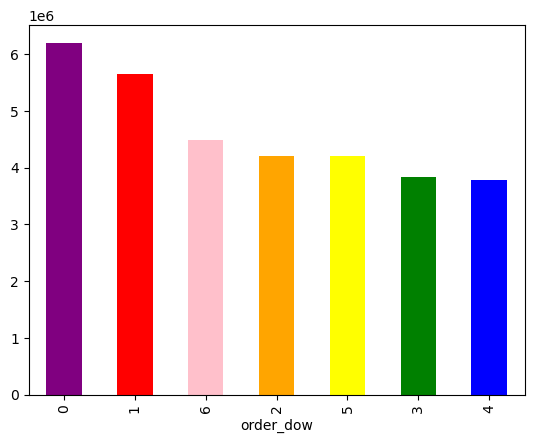

In [16]:
# Save the bar chart within the bar object (it can be accessed by using the function bar.figure)
bar=df_exe409['order_dow'].value_counts().plot.bar(color=['purple', 'red', 'pink', 'orange', 'yellow', 'green', 'blue'])

In [18]:
# Export the bar chart as an image file to a specific folder using the function figure.savefig()
bar.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'bar_order_dow.png'))

### Histograms

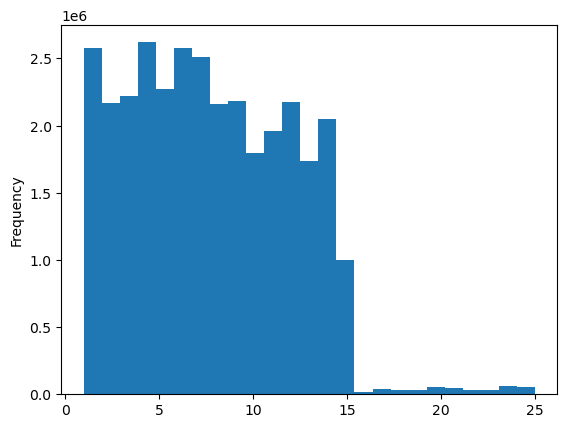

In [21]:
# Create a histogram chart for column “prices” (the argument within the parentheses it helps to determine the granularity of the histogram)
hist=df_exe409['prices'].plot.hist(bins = 25)

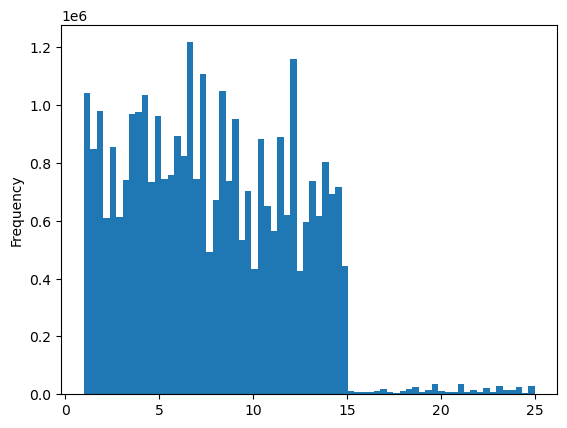

In [23]:
# Increase the granularity of the histogram by increasing the number of bins from 25 to 70
hist2=df_exe409['prices'].plot.hist(bins = 70)

In [25]:
# Export the histogram chart as an image file to a specific folder using the function figure.savefig():
hist.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'hist_prices_g25.png'))

In [27]:
# Export the histogram chart number 2 as an image file to a specific folder using the function figure.savefig():
hist2.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'hist_prices_g70.png'))

### Line charts

Create a line chart about the development of the column “prices” across the days of the week.
To achieve this, you would plot the column “order_dow” on the x-axis and the column "prices” on the y-axis.

What Does This Code Do?
1 Groups your data by order_dow, which represents days of the week (e.g., 0 = Sunday, 1 = Monday, etc.).
2 Calculates the average price (prices) for each day.
3 Creates a line chart where: The x-axis shows days of the week (order_dow). The y-axis shows average prices.
4 Customizes and displays a clean visualization with labels, grid lines, and markers.

In [32]:
# Grouping data by 'order_dow' and calculating the mean of 'prices'
prices_by_dow = df_exe409.groupby('order_dow')['prices'].mean()

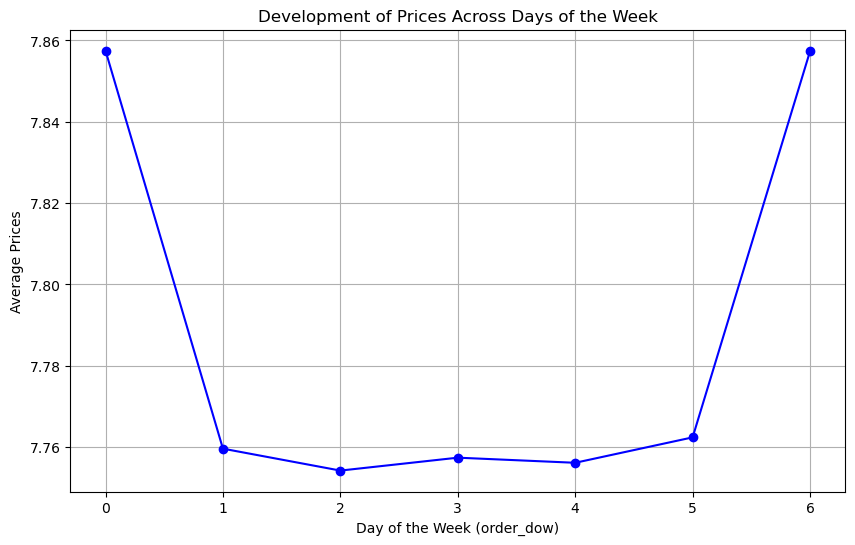

In [34]:
# Creating the line chart by creating a figure explicitly and store reference:
fig1 = plt.figure(figsize=(10, 6))
plt.plot(prices_by_dow.index, prices_by_dow.values, marker='o', linestyle='-', color='blue')
plt.title('Development of Prices Across Days of the Week')
plt.xlabel('Day of the Week (order_dow)')
plt.ylabel('Average Prices')
plt.grid(True)

In [36]:
# Save the line chart plot to a file before exporting to a folder
fig1.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'plt_prices_across_dow.png'), dpi=300, bbox_inches='tight')

### Sampling Data

In [41]:
# create samples
np.random.seed(4)
dev = np.random.rand(len(df_exe409)) <= 0.7

In [43]:
dev

array([False,  True, False, ...,  True,  True,  True])

In [47]:
# Create a list holding True/FAlse values to the test np.random.rand()<=0.7
dev1=np.random.rand(len(df_exe409))<=0.7

In [49]:
# Store 70% of the sample in the data-frame "big1"
big1=df_exe409[dev1]

In [51]:
# Store 30% of the sample in the data-frame "small1"
small1=df_exe409[~dev1]

In [55]:
# Check lenght of data-frame df_exe409
len(df_exe409)

32404859

In [57]:
# Check the total length of the data-frames big1 and small1
len(big1)+len(small1)

32404859

In [59]:
# Reducing the size of the data-frame to only those columns necessary for the chart (“prices” and “orders_day_of_week”)
df_2=small1[['order_dow', 'prices']]

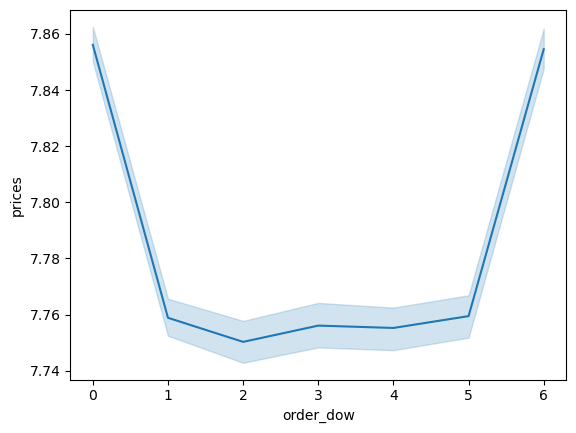

In [63]:
# Create line chart using the data-frame newly created (df_2)
line = sns.lineplot(data = df_2, x = 'order_dow',y = 'prices')

In [65]:
# Repeat the same exercise with data-frame "big1" - Reducing the size of the data-frame to only those columns necessary for the chart (“prices” and “orders_day_of_week”)
df_3=big1[['order_dow', 'prices']]

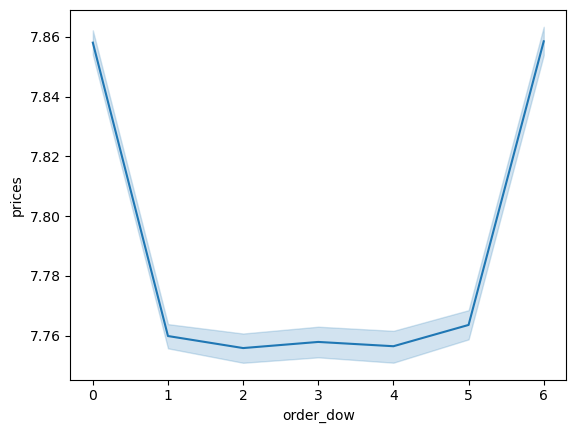

In [67]:
# Create line chart using the data-frame newly created (df_3)
line = sns.lineplot(data = df_3, x = 'order_dow',y = 'prices')

# Close